# `MeanRisk` objectives

`MeanRisk` is the workhorse optimiser: it casts portfolio selection as an explicit
trade-off between expected return and risk, and an **objective function** decides *which* point on
that trade-off you get. The same estimator, prior and risk measure can produce four very different
portfolios depending on the objective:

  - `MinimumRisk` — ignore return, take the least-risk portfolio.
  - `MaximumReturn` — ignore risk, take the highest-return portfolio (a corner solution).
  - `MaximumRatio` — maximise the risk-adjusted ratio (return over risk, net of the
    risk-free rate) — the tangency portfolio.
  - `MaximumUtility` — maximise `return − l · risk`, where the risk-aversion `l` dials
    continuously between the return-seeking and risk-averse ends.

This page runs all four against a common benchmark, confirms each does what it claims, and shows how
`MaximumUtility`'s risk-aversion parameter sweeps between the extremes.

> **When to reach for this**
>
> `MeanRisk` is the workhorse optimiser: reach for it whenever you want to express
> a portfolio as an explicit *trade-off between expected return and risk* and let a single
> objective pick the point — minimise risk, maximise return, maximise the risk-adjusted
> ratio, or maximise a risk-averse utility. If you instead want to *allocate risk itself*
> rather than trade it against return, see `RiskBudgeting`; if you want the whole
> trade-off curve rather than one point, see the [efficient-frontier](02_Efficient_Frontier.md)
> example.

In [1]:
using PortfolioOptimisers, PrettyTables
# Format for pretty tables.
tsfmt = (v, i, j) -> begin
    if j == 1
        return Date(v)
    else
        return v
    end
end;
resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v*100, digits=3)) %" : v
    end
end;

## 1. ReturnsResult data

We use the same S&P 500 slice as the other optimiser examples.

In [2]:
using CSV, TimeSeries, DataFrames

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
pretty_table(X[(end - 5):end]; formatters = [tsfmt])

# Compute the returns
rd = prices_to_returns(X)

┌────────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬──────
│  timestamp │    AAPL │     AMD │     BAC │     BBY │     CVX │      GE │     ⋯
│       Date │ Float64 │ Float64 │ Float64 │ Float64 │ Float64 │ Float64 │ Flo ⋯
├────────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼──────
│ 2022-12-20 │ 131.916 │   65.05 │  31.729 │  77.371 │ 169.497 │  62.604 │ 310 ⋯
│ 2022-12-21 │ 135.057 │   67.68 │  32.212 │  78.729 │  171.49 │   64.67 │ 314 ⋯
│ 2022-12-22 │ 131.846 │   63.86 │  31.927 │  78.563 │ 168.918 │  63.727 │ 311 ⋯
│ 2022-12-23 │ 131.477 │   64.52 │  32.005 │  79.432 │  174.14 │  63.742 │ 314 ⋯
│ 2022-12-27 │ 129.652 │   63.27 │  32.065 │   79.93 │ 176.329 │  64.561 │ 314 ⋯
│ 2022-12-28 │ 125.674 │   62.57 │  32.301 │  78.279 │ 173.728 │  63.883 │  31 ⋯
└────────────┴─────────┴─────────┴─────────┴─────────┴─────────┴─────────┴──────
                                                              14 columns omitted


ReturnsResult
    nx ┼ 20-element Vector{String}
     X ┼ 252×20 Matrix{Float64}
    nf ┼ nothing
     F ┼ nothing
    nb ┼ nothing
     B ┼ nothing
    ts ┼ 252-element Vector{Date}
    iv ┼ nothing
  ivpa ┴ nothing


## 2. The four objectives

We will hold the risk measure fixed and vary only the objective. For the risk measure we reach for
the **semi–standard deviation** — and here we meet a consequence of the package's design
philosophy: an entire class of risk measures is expressed as a single
`LowOrderMoment` parametrised by an internal algorithm. Semi–standard deviation is the
second lower partial moment (`Semi()`) rendered as a second-order cone expression
(`SOCRiskExpr`).

In [3]:
using Clarabel
slv = Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))

r = LowOrderMoment(; alg = SecondMoment(; alg1 = Semi(), alg2 = SOCRiskExpr()))

LowOrderMoment
  settings ┼ RiskMeasureSettings
           │   scale ┼ Float64: 1.0
           │      ub ┼ nothing
           │     rke ┴ Bool: true
         w ┼ nothing
        mu ┼ nothing
       alg ┼ SecondMoment
           │     ve ┼ SimpleVariance
           │        │          me ┼ nothing
           │        │           w ┼ nothing
           │        │   corrected ┴ Bool: true
           │   alg1 ┼ Semi()
           │   alg2 ┴ SOCRiskExpr()


Since every optimisation runs on the same data, we precompute the prior statistics once with
`EmpiricalPrior` and pass the result to `JuMPOptimiser`, so they are not recomputed
on every call.

In [4]:
pr = prior(EmpiricalPrior(), rd)
opt = JuMPOptimiser(; pe = pr, slv = slv)

JuMPOptimiser
       pe ┼ LowOrderPrior
          │         X ┼ 252×20 Matrix{Float64}
          │        mu ┼ 20-element Vector{Float64}
          │     sigma ┼ 20×20 Matrix{Float64}
          │      chol ┼ nothing
          │         w ┼ nothing
          │       ens ┼ nothing
          │       kld ┼ nothing
          │        ow ┼ nothing
          │        rr ┼ nothing
          │      f_mu ┼ nothing
          │   f_sigma ┼ nothing
          │       f_w ┴ nothing
      slv ┼ Solver
          │          name ┼ Symbol: :clarabel1
          │        solver ┼ UnionAll: Clarabel.MOIwrapper.Optimizer
          │      settings ┼ Dict{String, Bool}: Dict{String, Bool}("verbose" => 0)
          │     check_sol ┼ @NamedTuple{allow_local::Bool, allow_almost::Bool}: (allow_local = true, allow_almost = true)
          │   add_bridges ┴ Bool: true
       wb ┼ WeightBounds
          │   lb ┼ Float64: 0.0
          │   ub ┴ Float64: 1.0
      bgt ┼ Float64: 1.0
     sbgt ┼ nothing
       lt ┼ noth

> **Precomputed result vs estimator**
>
> Passing `pe = pr` — the *result* of `prior(...)` — fixes the statistics once and reuses them
> on every `optimise` call, which is why we need not pass the returns data again. But you can
> instead hand the optimiser the **estimator itself**, `pe = EmpiricalPrior()`, and call
> `optimise(model, rd)`; the prior is then recomputed from whatever data the optimiser is
> given. Most examples here precompute for speed because they solve repeatedly on one fixed
> slice, but the estimator form is the one to reach for whenever the data changes underneath
> the optimiser:

      - **Cross-validation** refits on each training fold, so it *requires* the estimator form —
        a precomputed result (fit on the whole sample) would leak the test data into training,
        and is therefore disallowed.
      - **Meta-optimisers** (`Stacking`, `NestedClustered`) feed their *outer*
        optimiser synthetic returns assembled from the inner solves, where a precomputed
        asset-level prior is meaningless; that slot takes an estimator (or just a solver).

    Both are shown in the [meta-optimisers](13_Meta_Optimisers.md) and
    [subset resampling / cross-validation](14_Subset_Resampling_and_Cross_Validation.md) examples.

Now the four objectives. Only the `obj` field changes — same prior, same risk measure, same
optimiser.

In [5]:
# Minimum risk
mr1 = MeanRisk(; r = r, obj = MinimumRisk(), opt = opt)
# Maximum utility (default risk aversion l = 2)
mr2 = MeanRisk(; r = r, obj = MaximumUtility(), opt = opt)
# Maximum risk-adjusted ratio, risk-free rate of 4.2/100/252
rf = 4.2 / 100 / 252
mr3 = MeanRisk(; r = r, obj = MaximumRatio(; rf = rf), opt = opt)
# Maximum return
mr4 = MeanRisk(; r = r, obj = MaximumReturn(), opt = opt)

MeanRisk
  opt ┼ JuMPOptimiser
      │        pe ┼ LowOrderPrior
      │           │         X ┼ 252×20 Matrix{Float64}
      │           │        mu ┼ 20-element Vector{Float64}
      │           │     sigma ┼ 20×20 Matrix{Float64}
      │           │      chol ┼ nothing
      │           │         w ┼ nothing
      │           │       ens ┼ nothing
      │           │       kld ┼ nothing
      │           │        ow ┼ nothing
      │           │        rr ┼ nothing
      │           │      f_mu ┼ nothing
      │           │   f_sigma ┼ nothing
      │           │       f_w ┴ nothing
      │       slv ┼ Solver
      │           │          name ┼ Symbol: :clarabel1
      │           │        solver ┼ UnionAll: Clarabel.MOIwrapper.Optimizer
      │           │      settings ┼ Dict{String, Bool}: Dict{String, Bool}("verbose" => 0)
      │           │     check_sol ┼ @NamedTuple{allow_local::Bool, allow_almost::Bool}: (allow_local = true, allow_almost = true)
      │           │   add_br

We optimise each. Because the prior is precomputed, we do not pass the returns data. For a
reference point we also compute an `InverseVolatility` benchmark — a naive, solver-free
allocation that ignores both objective and expected returns.

In [6]:
res1 = optimise(mr1)
res2 = optimise(mr2)
res3 = optimise(mr3)
res4 = optimise(mr4)
res0 = optimise(InverseVolatility(; pe = pr))

NaiveOptimisationResult
       oe ┼ DataType: DataType
       pr ┼ LowOrderPrior
          │         X ┼ 252×20 Matrix{Float64}
          │        mu ┼ 20-element Vector{Float64}
          │     sigma ┼ 20×20 Matrix{Float64}
          │      chol ┼ nothing
          │         w ┼ nothing
          │       ens ┼ nothing
          │       kld ┼ nothing
          │        ow ┼ nothing
          │        rr ┼ nothing
          │      f_mu ┼ nothing
          │   f_sigma ┼ nothing
          │       f_w ┴ nothing
       wb ┼ WeightBounds
          │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
          │   ub ┴ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
  retcode ┼ OptimisationSuccess
          │   res ┴ nothing
        w ┼ 20-element Vector{Float64}
       fb ┴ nothing


The weights side by side. Reading left to right, the benchmark spreads evenly, minimum-risk hugs
the low-volatility names, and maximum-return collapses onto the single highest-return asset.

In [7]:
pretty_table(DataFrame(; :assets => rd.nx, :benchmark => res0.w, :MinimumRisk => res1.w,
                       :MaximumUtility => res2.w, :MaximumRatio => res3.w,
                       :MaximumReturn => res4.w); formatters = [resfmt])

┌────────┬───────────┬─────────────┬────────────────┬──────────────┬────────────
│ assets │ benchmark │ MinimumRisk │ MaximumUtility │ MaximumRatio │ MaximumRe ⋯
│ String │   Float64 │     Float64 │        Float64 │      Float64 │       Flo ⋯
├────────┼───────────┼─────────────┼────────────────┼──────────────┼────────────
│   AAPL │   4.004 % │       0.0 % │          0.0 % │        0.0 % │         0 ⋯
│    AMD │   2.332 % │       0.0 % │          0.0 % │        0.0 % │         0 ⋯
│    BAC │    4.39 % │       0.0 % │          0.0 % │        0.0 % │         0 ⋯
│    BBY │   3.143 % │       0.0 % │          0.0 % │        0.0 % │         0 ⋯
│    CVX │   4.326 % │     8.817 % │        6.884 % │        0.0 % │         0 ⋯
│     GE │   4.087 % │       0.0 % │          0.0 % │        0.0 % │         0 ⋯
│     HD │    4.55 % │       0.0 % │          0.0 % │        0.0 % │         0 ⋯
│    JNJ │   8.175 % │    49.192 % │       39.727 % │        0.0 % │         0 ⋯
│    JPM │   4.771 % │     3

## 3. Risk aversion: tuning `MaximumUtility`

`MinimumRisk` and `MaximumReturn` are the two extremes of the trade-off.
`MaximumUtility` interpolates between them: it maximises `return − l · risk`, so the
risk-aversion `l` is the dial. As `l → 0` utility chases return (toward the maximum-return corner);
as `l` grows large the risk term dominates (toward the minimum-risk portfolio). The default is
`l = 2`.

We sweep a range of `l` and read off the realised risk and return of each portfolio.

In [8]:
lambdas = [1, 2, 8, 32, 128]
util = [optimise(MeanRisk(; r = r, obj = MaximumUtility(; l = l), opt = opt))
        for l in lambdas]

sweep = map(zip(lambdas, util)) do (l, res)
    rk, rt, rr = expected_risk_ret_ratio(r, res.ret, res.w, res.pr; rf = rf)
    return (l, rk, rt, rr)
end
pretty_table(DataFrame(; Symbol("risk aversion l") => [s[1] for s in sweep],
                       :risk => [s[2] for s in sweep], :return => [s[3] for s in sweep],
                       :ratio => [s[4] for s in sweep]); formatters = [resfmt],
             title = "MaximumUtility: higher l ⇒ lower risk and lower return")

MaximumUtility: higher l ⇒ lower risk and lower return
┌─────────────────┬─────────┬─────────┬──────────┐
│ risk aversion l │    risk │  return │    ratio │
│           Int64 │ Float64 │ Float64 │  Float64 │
├─────────────────┼─────────┼─────────┼──────────┤
│               1 │ 0.673 % │ 0.119 % │ 15.256 % │
│               2 │ 0.657 % │ 0.098 % │ 12.333 % │
│               8 │ 0.651 % │ 0.081 % │  9.826 % │
│              32 │ 0.651 % │ 0.076 % │  9.135 % │
│             128 │ 0.651 % │ 0.075 % │  8.958 % │
└─────────────────┴─────────┴─────────┴──────────┘


Both risk and return fall monotonically as `l` rises — the portfolio slides down the frontier from
the return-seeking end toward the minimum-risk end. Plotting the realised (risk, return) of each
step traces that path explicitly.

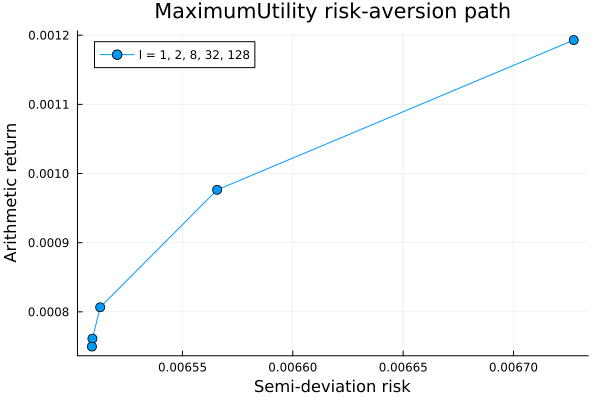

In [9]:
using StatsPlots, GraphRecipes

plot([s[2] for s in sweep], [s[3] for s in sweep]; seriestype = :path,
     marker = (:circle, 5), xlabel = "Semi-deviation risk", ylabel = "Arithmetic return",
     title = "MaximumUtility risk-aversion path",
     label = "l = " * join(string.(lambdas), ", "))

## 4. Confirming the objectives

To check each objective did what it says on the tin, we compute the risk, return and risk-return
ratio of every portfolio. There are individual functions (`expected_risk`,
`expected_return`, `expected_ratio`), but `expected_risk_ret_ratio` returns
all three at once, which is what we use here.

Any function that computes the expected portfolio return needs to know *which* return type to use;
we stay consistent with the return measure used in each optimisation.

In [10]:
rk1, rt1, rr1 = expected_risk_ret_ratio(r, res1.ret, res1.w, res1.pr; rf = rf);
rk2, rt2, rr2 = expected_risk_ret_ratio(r, res2.ret, res2.w, res2.pr; rf = rf);
rk3, rt3, rr3 = expected_risk_ret_ratio(r, res3.ret, res3.w, res3.pr; rf = rf);
rk4, rt4, rr4 = expected_risk_ret_ratio(r, res4.ret, res4.w, res4.pr; rf = rf);
rk0, rt0, rr0 = expected_risk_ret_ratio(r, ArithmeticReturn(), res0.w, res0.pr; rf = rf);

The table confirms it: `MinimumRisk` posts the lowest risk, `MaximumRatio` the highest ratio, and
`MaximumReturn` the highest return — each column extremised on its own objective.

In [11]:
pretty_table(DataFrame(;
                       :obj =>
                           [:MinimumRisk, :MaximumUtility, :MaximumRatio, :MaximumReturn,
                            :Benchmark], :rk => [rk1, rk2, rk3, rk4, rk0],
                       :rt => [rt1, rt2, rt3, rt4, rt0], :rr => [rr1, rr2, rr3, rr4, rr0]);
             formatters = [resfmt])

┌────────────────┬─────────┬─────────┬──────────┐
│            obj │      rk │      rt │       rr │
│         Symbol │ Float64 │ Float64 │  Float64 │
├────────────────┼─────────┼─────────┼──────────┤
│    MinimumRisk │ 0.651 % │ 0.075 % │  8.899 % │
│ MaximumUtility │ 0.657 % │ 0.098 % │ 12.333 % │
│   MaximumRatio │ 0.829 % │ 0.196 % │ 21.611 % │
│  MaximumReturn │ 1.621 % │ 0.264 % │ 15.236 % │
│      Benchmark │ 0.813 % │ 0.025 % │   0.97 % │
└────────────────┴─────────┴─────────┴──────────┘


## 5. Visualising the objectives

The stacked-bar composition contrasts the five allocations at a glance — note how the
return-driven objectives concentrate while the benchmark and minimum-risk books spread out.

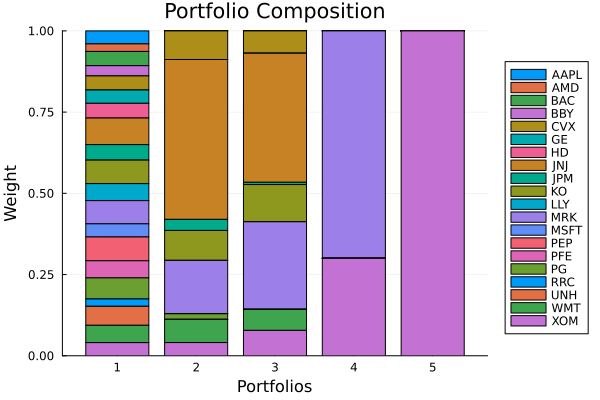

In [12]:
plot_stacked_bar_composition([res0, res1, res2, res3, res4], rd)

The return histogram for the minimum-risk portfolio shows the distribution of daily returns and the
VaR / CVaR tail-risk markers.

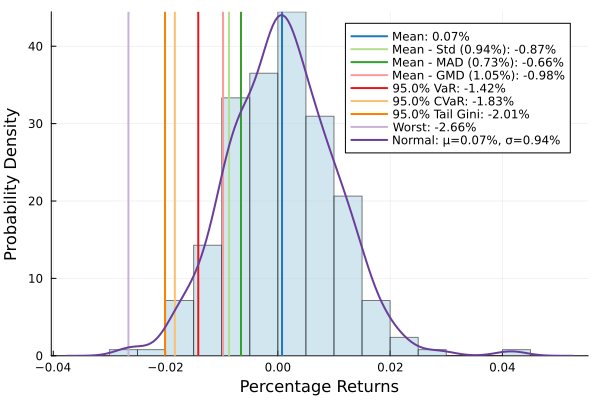

In [13]:
plot_histogram(res1, rd)

Drawdown time series for the minimum-risk portfolio.

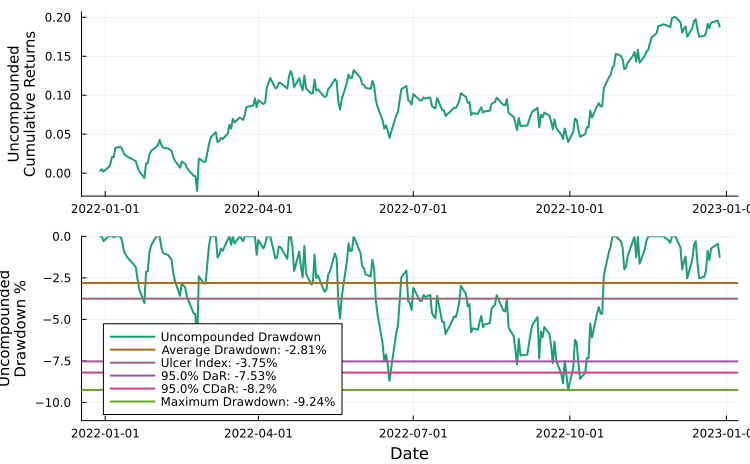

In [14]:
plot_drawdowns(res1, rd)

Per-asset semi-standard-deviation risk contribution for the minimum-risk portfolio.

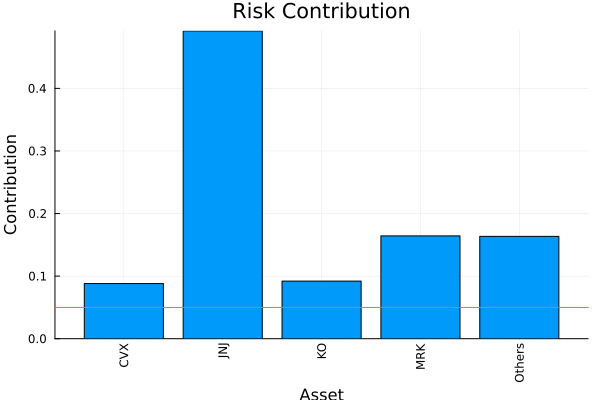

In [15]:
plot_risk_contribution(r, res1, rd)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*